The following cell locates the pyresdmd package.

In [1]:
from pathlib import Path
import sys


def _find_repo_root(start: Path) -> Path:
    for path in [start, *start.parents]:
        if (path / "pyproject.toml").exists() and (path / "pyresdmd").exists():
            return path
    raise RuntimeError("Could not find repo root containing pyproject.toml and pyresdmd/")


REPO_ROOT = _find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print("Found pyresdmd root.")

Found pyresdmd root.


The following cell sorts out imports. matplotlib is imported for visualization.  

In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from pyresdmd.dicts.hermite_dictionary import HermiteDictionary
from pyresdmd.dicts import TensorProductDictionary
from pyresdmd.dicts.nn.relu.relu_dictionary import ReLUDictionary
from pyresdmd.dicts.trainable_dictionary import TrainableDictionary
from pyresdmd.compute.spectra import (
    compute_eigendecomposition_from_weights,
    compute_pseudospectra,
)
from pyresdmd.utils.helpers import benchmark_metrics
from pyresdmd.utils.plotters import plot_curve, plot_pseudospec
from pyresdmd.sims.undamped_harmonic import undamped_harmonic_cts

print("Imports successful.")

Imports successful.


The following cell enables GPU acceleration if a CUDA-enabled GPU is available. Note that the CUDA version of pytorch must be installed. 

Defaults are tested on an RTX 3060 Laptop with 6GB VRAM, though this simulation tended to use less than 0.5GB.

In [3]:
if torch.cuda.is_available():
    print("CUDA is available. Using GPU for computations.")
    device = torch.device("cuda")
else:
    print("No CUDA-supported device found. Using CPU for computations.")
    device = torch.device("cpu")

CUDA is available. Using GPU for computations.


Modify the values in the following cell to change the parameters of the simulation. Ensure that the type of the value matches the annotation. Be wary that runtime and memory can scale nonlinearly in these parameters, and so one should increase values incramentally. 

In [4]:
# change this cell to change simulation parameters
noise : float = 0.0
n_trajectories : int = 300
steps : int = 60
epochs : int = 500
patience : int = 50
dictionary_size : int = 36
dt : float = 0.5
k : float = 1.0

print("Simulation parameters set.")

Simulation parameters set.


The following cell sorts out trajectory generation. Modify rand_point to change how initial points are selected.

In [5]:
def rand_point() -> torch.Tensor:
        '''Generates a random point in the state space. We pick a radius uniformly from [-1, 1]^2'''
        return 2*torch.rand(2, device = device) - 1 # sample uniformly from [-3, 3]^2

initial_states = [rand_point() for _ in range(n_trajectories)]
x, y = undamped_harmonic_cts(initial_states, dt = dt, k = k, steps = steps, noise = noise, device = device)

print("Trajectory data generated.")

Trajectory data generated.


The following cell plots the generated trajectory.

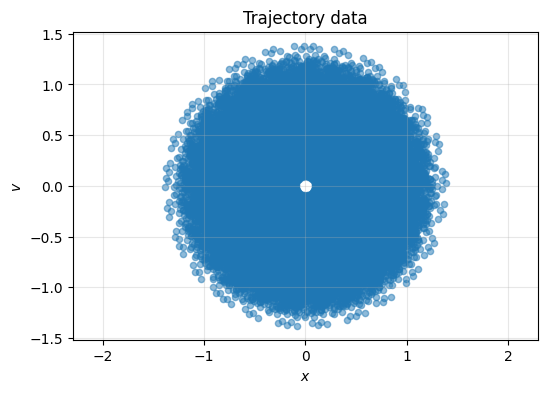

In [6]:
plt.figure(figsize=(6, 4))
plt.scatter(x.cpu().detach().numpy()[:,0], x.cpu().detach().numpy()[:,1], alpha=0.5, s=20)
plt.xlabel('$x$')
plt.ylabel('$v$')
plt.title('Trajectory data')
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

The following cell sets up a trainable dictionary with ReLU activation functions, with appropriate initialization. We then compute EDMD eigenvalues and condition number, alongside loss and normalized forecast error. We also give a pseudospectral plot. We will compare this to our final trained dictionary.

Dictionary generated.


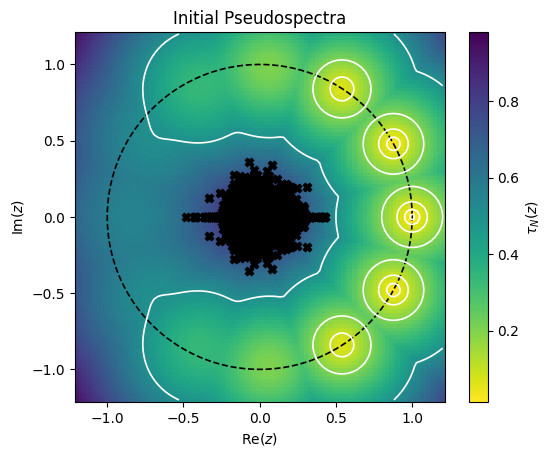

In [ ]:
# generates trainable dictionary and computes initial metrics.
base = ReLUDictionary(input_dim = 2, n_functions = dictionary_size)
dictionary = TrainableDictionary(base)
print("Dictionary generated.")
dictionary.to(device)

with torch.no_grad():
    report = dictionary.report(x, y, verbose = False)
    Psi_X, Psi_Y = dictionary.evaluate(x), dictionary.evaluate(y)
init_eigvals = report['eigenvalues']
init_loss = report['loss']
init_cond_num = report['cond_num']
init_forecast_error = report['forecast_error']
Psi_X, Psi_Y = dictionary.evaluate(x), dictionary.evaluate(y)
W = dictionary._weight_tensor(x.shape[0], None, device = x.device, dtype = x.dtype)
_, init_eigvals = compute_eigendecomposition_from_weights(Psi_X, Psi_Y, W)
init_pseudospec = compute_pseudospectra(Psi_X, Psi_Y)
eps_levels = [1e-3, 2e-3, 5e-3, 1e-2, 2e-2, 5e-2, 1e-1, 2e-1, 5e-1]

print(f"Initial eigenvalues: {init_eigvals}")
print(f"Initial loss: {init_loss}")
print(f"Initial condition number: {init_cond_num}")
print(f"Initial forecast error: {init_forecast_error}")

re_vals = init_pseudospec['re_vals']
im_vals = init_pseudospec['im_vals']
tau_grid = init_pseudospec['tau_grid']

plot_pseudospec(re_vals, im_vals, tau_grid, eps_levels, unit_circle = True, eigvals = init_eigvals, displayname = 'Initial Pseudospectra', save = False)


For the sake of comparison, we do the same for a deterministic benchmark. In this case, $$\{(x, y) \mapsto H_i(x)H_j(x) : 0 \le i, j \le |\mathcal D|^{1/2} - 1\},$$ giving a dictionary size of $$|\mathcal D|.$$

Hermite eigvals: tensor([-0.9750+0.1395j, -0.9750-0.1395j, -0.9002+0.3397j, -0.9002-0.3397j,
        -0.8011+0.5985j, -0.8011-0.5985j, -0.6215+0.6594j, -0.6215-0.6594j,
        -0.5460+0.0000j, -0.4161+0.9093j, -0.4161-0.9093j, -0.3512+0.3626j,
        -0.3512-0.3626j, -0.2494+0.8111j, -0.2494-0.8111j, -0.2523+0.7800j,
        -0.2523-0.7800j,  0.1949+0.0000j,  0.5328+0.0000j,  0.0707+0.9975j,
         0.0707-0.9975j,  0.0707+0.9975j,  0.0707-0.9975j,  1.0000+0.0000j,
         1.0000+0.0000j,  1.0000+0.0000j,  0.5403+0.8415j,  0.5403-0.8415j,
         0.5403+0.8415j,  0.5403-0.8415j,  0.8776+0.4794j,  0.8776-0.4794j,
         0.8776+0.4794j,  0.8776-0.4794j,  0.8776+0.4794j,  0.8776-0.4794j],
       device='cuda:0')
Hermite loss: 0.2399541139602661
Hermite condition number: 4682197.0
Hermite forecast error: 0.0044085076078772545


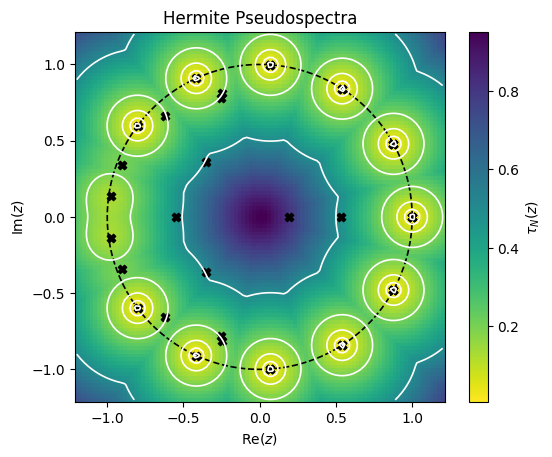

In [8]:
# generates benchmark dictionary and gives statistics
size = int(dictionary_size**0.5) - 1
hermite_dict = TensorProductDictionary(HermiteDictionary(size), HermiteDictionary(size))
hermite_dict.to(device)
with torch.no_grad():
    hermite_metrics = benchmark_metrics(hermite_dict, x, y)
hermite_eigvals = hermite_metrics['Lambda']
hermite_cond_num = hermite_metrics['cond_num']
hermite_loss = hermite_metrics['loss']
hermite_forecast_error = hermite_metrics['forecast_error']
hermite_pseudospec = hermite_metrics['pseudospec']

print(f"Hermite eigvals: {hermite_eigvals}")
print(f"Hermite loss: {hermite_loss}")
print(f"Hermite condition number: {hermite_cond_num}")
print(f"Hermite forecast error: {hermite_forecast_error}")

re_vals = hermite_pseudospec['re_vals']
im_vals = hermite_pseudospec['im_vals']
tau_grid = hermite_pseudospec['tau_grid']
plot_pseudospec(re_vals, im_vals, tau_grid, eps_levels, unit_circle = True, eigvals = hermite_eigvals, displayname = 'Hermite Pseudospectra', save = False)
del re_vals, im_vals, tau_grid, hermite_pseudospec

We now train our dictionary using the ResDMD loss and present the same statistics for the trained dictionary. We note significant improvements in loss, lack of spectral pollution and forecast error compared to the untrained dictionary and Hermite benchmark.

In [ ]:
trained = dictionary.fit(x, y, epochs = epochs, patience = patience)
train_losses = trained['train_losses']
test_losses = trained['test_losses']
train_cond_nums = trained['train_cond_nums']
test_cond_nums = trained['test_cond_nums'] 
train_forecast_errors = trained['train_forecast_errors']
test_forecast_errors = trained['test_forecast_errors']
final_epoch = trained['final_epoch']

with torch.no_grad():
    best_report = dictionary.report(x, y)
    Psi_X, Psi_Y = dictionary.evaluate(x), dictionary.evaluate(y)
best_loss = best_report['loss']
best_cond_num = best_report['cond_num']
best_forecast_error = best_report['forecast_error']
final_pseudospec = compute_pseudospectra(Psi_X, Psi_Y) 
W = torch.ones(x.shape[0], device = x.device) / x.shape[0]
final_eigvals, _ = compute_eigendecomposition_from_weights(Psi_X, Psi_Y, W)

print(f"Best loss: {best_loss}")
print(f"Condition number of best model: {best_cond_num}")
print(f"Forecast error of best model: {best_forecast_error}")
re_vals = final_pseudospec['re_vals']
im_vals = final_pseudospec['im_vals']
tau_grid = final_pseudospec['tau_grid']
plot_pseudospec(re_vals, im_vals, tau_grid, eps_levels, unit_circle = True, eigvals = final_eigvals, displayname = 'Hermite Pseudospectra', save = False)

The following cell toggles whether to show Hermite statistics on graph. 

In [ ]:
show_hermite_cond_num = False 
show_hermite_loss = True 
show_hermite_forecast_error = False

The following plots loss, condition number and forecast error curves, showing improvements over time for both training and test data. 

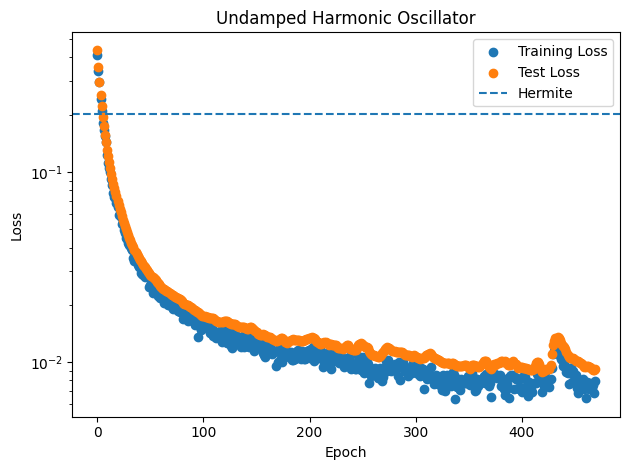

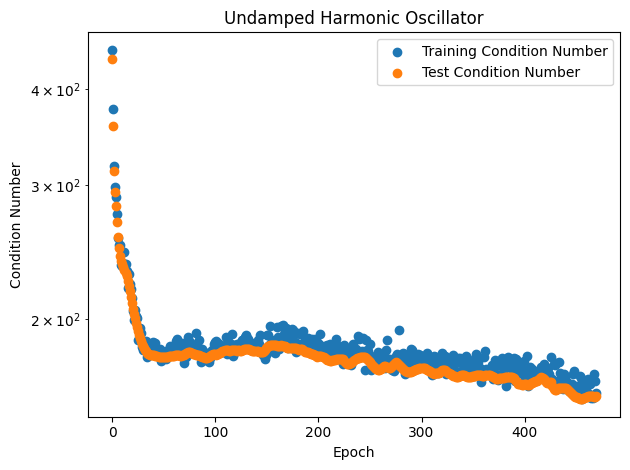

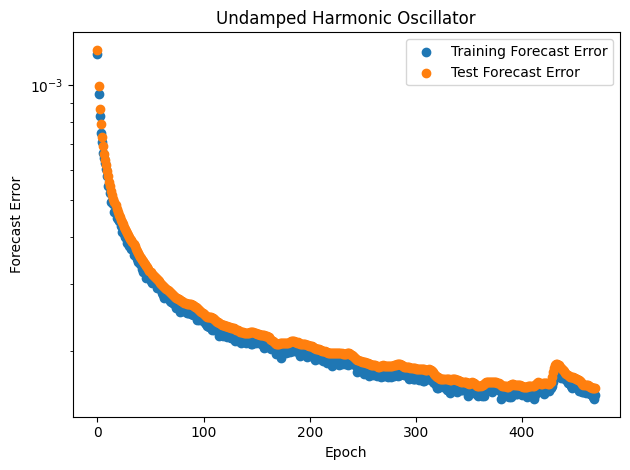

In [ ]:
add_values_loss = {'Hermite': hermite_loss} if show_hermite_loss else {}
add_values_cond_num = {'Hermite': hermite_cond_num} if show_hermite_cond_num else {}
add_values_forecast_error = {'Hermite': hermite_forecast_error} if show_hermite_forecast_error else {}

plot_curve(final_epoch, train_losses, test_losses, add_values = add_values_loss, 
                       displayname = 'Undamped Harmonic Oscillator', ylabel = 'Loss', save_plot = False)

plot_curve(final_epoch, train_cond_nums, test_cond_nums, add_values = add_values_cond_num,
                        displayname = 'Undamped Harmonic Oscillator', ylabel = 'Condition Number', save_plot = False)

plot_curve(final_epoch, train_forecast_errors, test_forecast_errors, add_values = add_values_forecast_error,
                        displayname = 'Undamped Harmonic Oscillator', ylabel = 'Forecast Error', save_plot = False)